In [2]:
## Import Library

import os
import math
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
## Load Dataset

project_root = Path().resolve().parent

df = pd.read_csv(project_root / 'data' / 'processed' / 'node_combined_final.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

In [4]:
## pisahin node menjadi per df

df1 = df[df['node'] == 1].copy()
df2 = df[df['node'] == 2].copy()
df3 = df[df['node'] == 3].copy()
df4 = df[df['node'] == 4].copy()
df5 = df[df['node'] == 5].copy()
df6 = df[df['node'] == 6].copy()

# tampilkan head df1-6
# for i in range(1, 7):
#     print(f"\nNode {i} (df{i}) head:")
#     print(globals()[f"df{i}"].head(1))

In [5]:
FEATURE_COLS = ["h2s", "so2", "hum", "temp", "windspeed", "hour", "minute", "minute_of_day", "h2s_diff", "so2_diff", "gas_ratio_so2_h2s"]
TARGET_COLS = ["h2s", "so2"]

In [ ]:
models = {}
# This dictionary will store y_test and y_pred for each node to be evaluated in the next cell
test_data_for_eval = {}

for i in range(1, 7):
    df_name = f"df{i}"
    if df_name not in globals():
        print(f"Warning: {df_name} not found. Skipping model training for this node.")
        continue

    #print(f"\n======== Training model for {df_name} (Node {i}) ========\n")
    df_node = globals()[df_name].copy()

    # Drop rows with NaN in features or targets
    df_node.dropna(subset=FEATURE_COLS + TARGET_COLS, inplace=True)

    X = df_node[FEATURE_COLS]
    y = df_node[TARGET_COLS]

    # Split data into training and testing sets
    # Using TimeSeriesSplit or a simple train_test_split can be considered
    # For simplicity, let's use train_test_split for now
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, shuffle=False
    )

    # Initialize XGBoost Regressor
    xgb_reg = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=100,
        learning_rate=0.1,
        random_state=SEED,
        n_jobs=-1 # Use all available cores
    )

    # Wrap XGBoost with MultiOutputRegressor
    multi_output_xgb = MultiOutputRegressor(xgb_reg)

    # Train the model
    multi_output_xgb.fit(X_train, y_train)

    # Store the trained model
    models[f'node_{i}'] = multi_output_xgb

    # Make predictions on the test set
    y_pred = multi_output_xgb.predict(X_test)

    # Store X_test, y_test and y_pred for later evaluation and visualization
    test_data_for_eval[f'node_{i}'] = {
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred
    }

print("\nModel training completed untuk semua node.")


======== Training model for df1 (Node 1) ========


======== Training model for df2 (Node 2) ========


======== Training model for df3 (Node 3) ========


======== Training model for df4 (Node 4) ========


======== Training model for df5 (Node 5) ========


======== Training model for df6 (Node 6) ========


Model training completed for all specified nodes.


In [ ]:
print("\n======== Model Evaluation ========\n")

evaluation_metrics_summary = {}

for i in range(1, 7):
    node_key = f'node_{i}'
    if node_key not in test_data_for_eval:
        print(f"Warning: No evaluation data found for {node_key}. Skipping evaluation.")
        continue

    y_test = test_data_for_eval[node_key]['y_test']
    y_pred = test_data_for_eval[node_key]['y_pred']

    node_metrics = {}
    print(f"\nEvaluation for Node {i}:")
    for j, target_col in enumerate(TARGET_COLS):
        mse = mean_squared_error(y_test[target_col], y_pred[:, j])
        rmse = np.sqrt(mse)  # Calculate RMSE
        mae = mean_absolute_error(y_test[target_col], y_pred[:, j])
        r2 = r2_score(y_test[target_col], y_pred[:, j])

        print(f"  Target: {target_col}")
        print(f"    Mean Squared Error (MSE): {mse:.4f}")
        print(f"    Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"    Mean Absolute Error (MAE): {mae:.4f}")
        print(f"    R-squared (R2): {r2:.4f}")
        node_metrics[target_col] = {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}
    evaluation_metrics_summary[node_key] = node_metrics

print("\nModel evaluation completed for all specified nodes.")


======== Model Evaluation ========


Evaluation for Node 1:
  Target: h2s
    Mean Squared Error (MSE): 24.6546
    Root Mean Squared Error (RMSE): 4.9653
    Mean Absolute Error (MAE): 1.7819
    R-squared (R2): 0.9973
  Target: so2
    Mean Squared Error (MSE): 151.5251
    Root Mean Squared Error (RMSE): 12.3096
    Mean Absolute Error (MAE): 5.2179
    R-squared (R2): 0.9973

Evaluation for Node 2:
  Target: h2s
    Mean Squared Error (MSE): 0.6161
    Root Mean Squared Error (RMSE): 0.7849
    Mean Absolute Error (MAE): 0.2016
    R-squared (R2): 0.9707
  Target: so2
    Mean Squared Error (MSE): 0.0008
    Root Mean Squared Error (RMSE): 0.0289
    Mean Absolute Error (MAE): 0.0120
    R-squared (R2): 1.0000

Evaluation for Node 3:
  Target: h2s
    Mean Squared Error (MSE): 54.1737
    Root Mean Squared Error (RMSE): 7.3603
    Mean Absolute Error (MAE): 4.1743
    R-squared (R2): 0.8874
  Target: so2
    Mean Squared Error (MSE): 1804.3523
    Root Mean Squared Error (RMSE): 4


======== Visualisasi Time-Series Prediksi vs. Aktual Model XGBosst ========


Visualisasi Time-Series untuk Node 1:


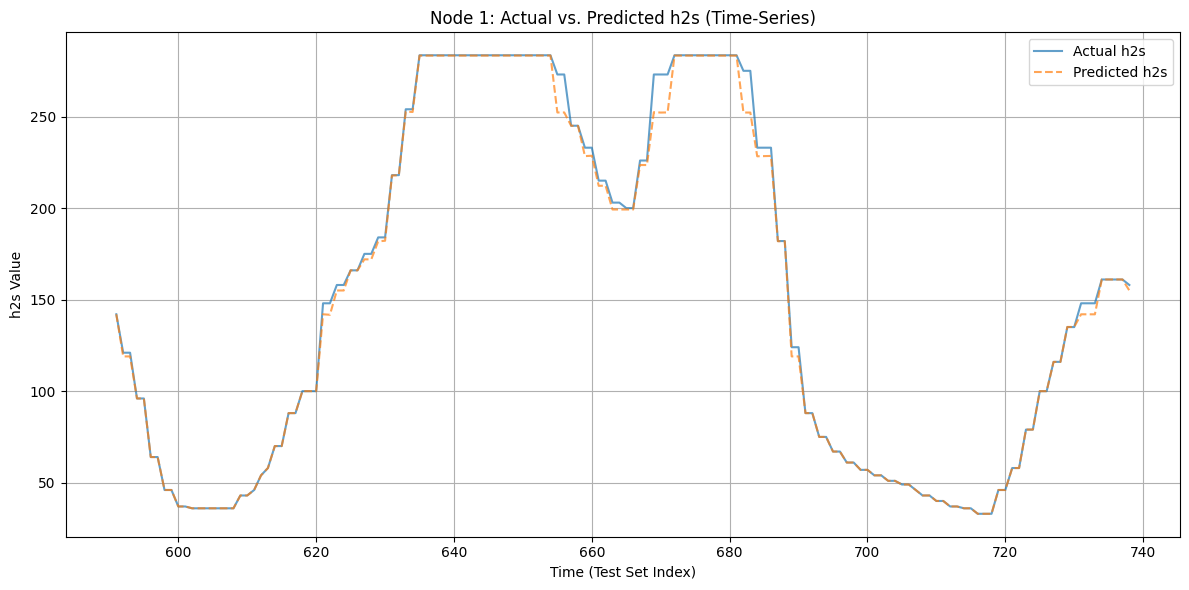

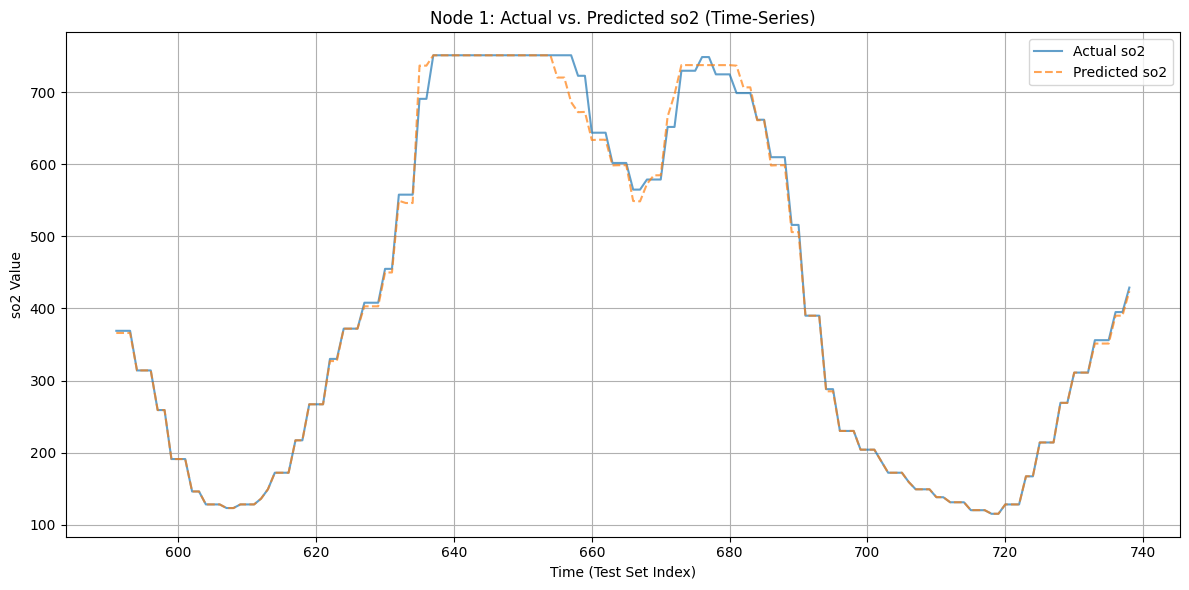


Visualisasi Time-Series untuk Node 2:


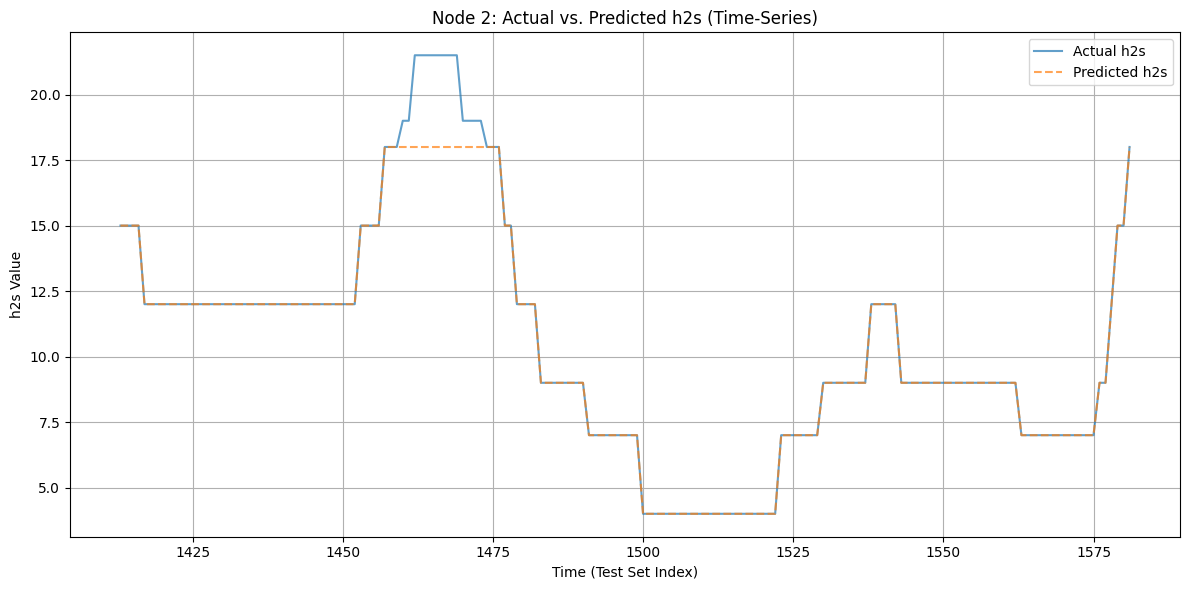

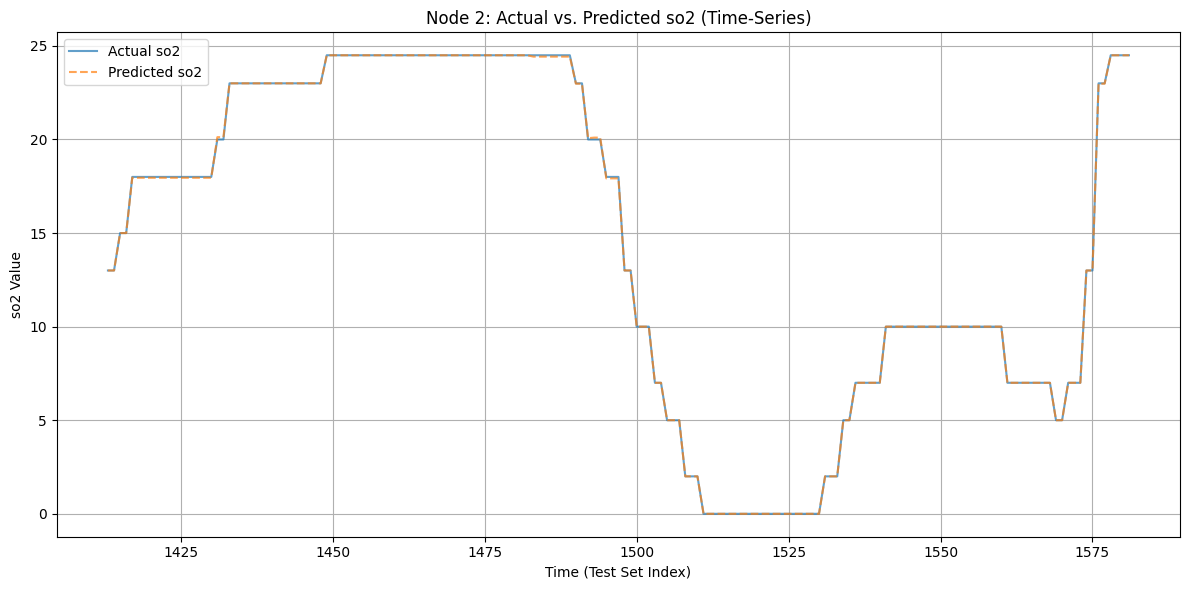


Visualisasi Time-Series untuk Node 3:


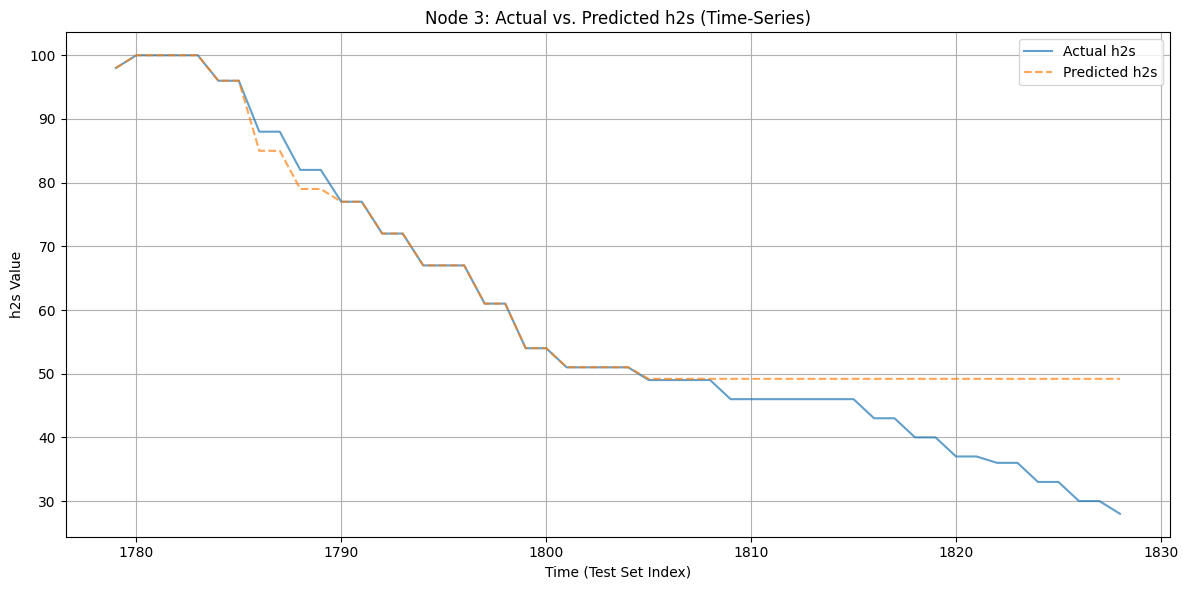

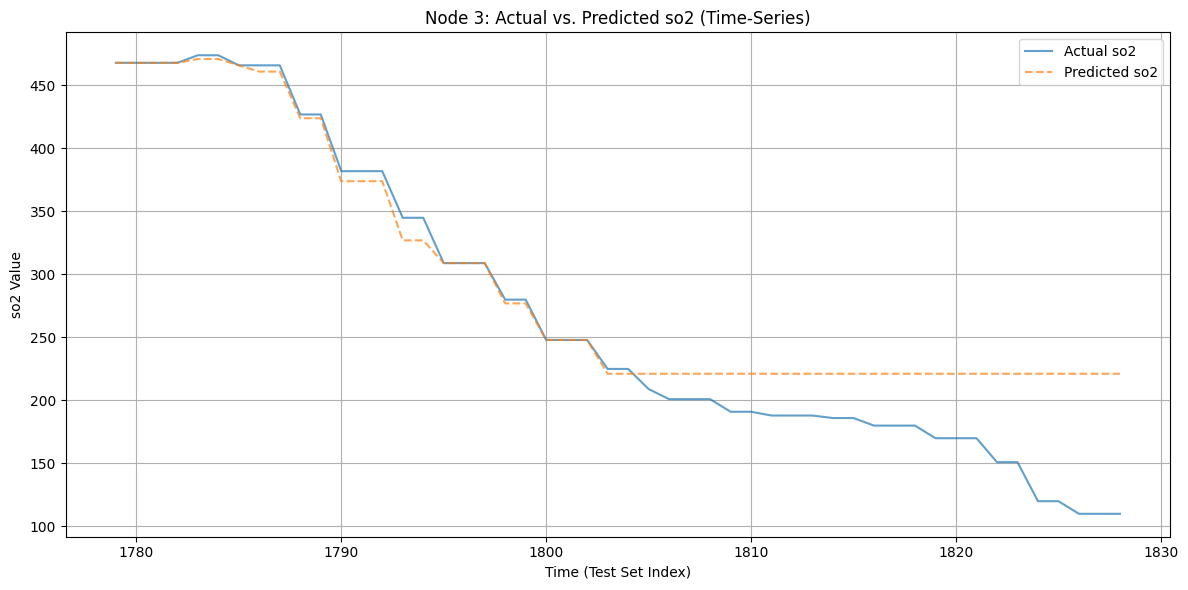


Visualisasi Time-Series untuk Node 4:


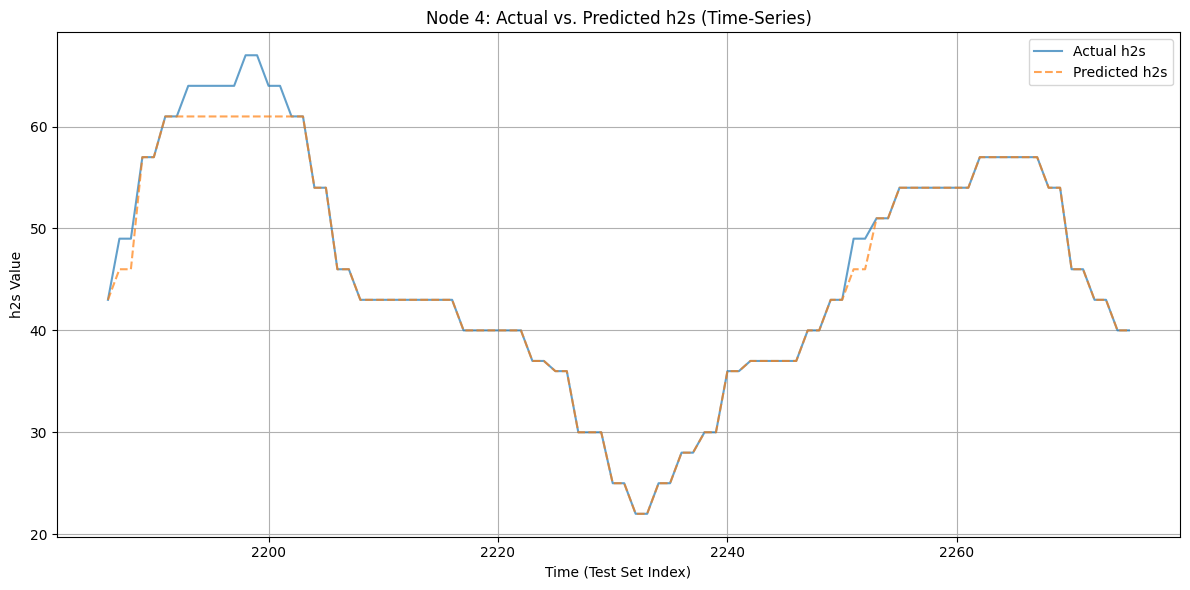

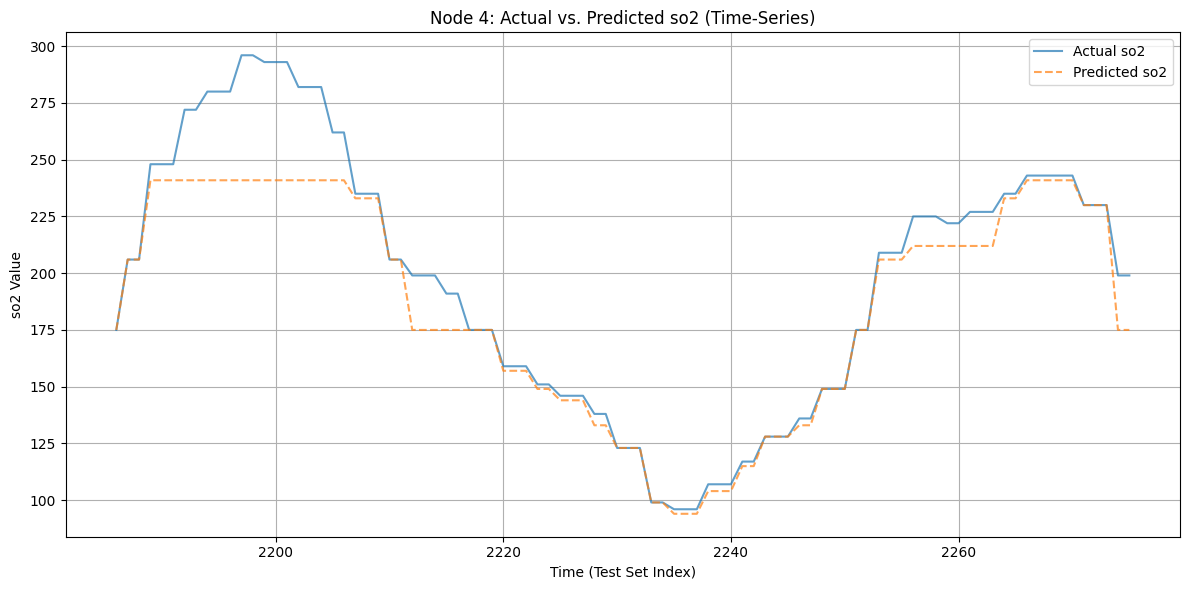


Visualisasi Time-Series untuk Node 5:


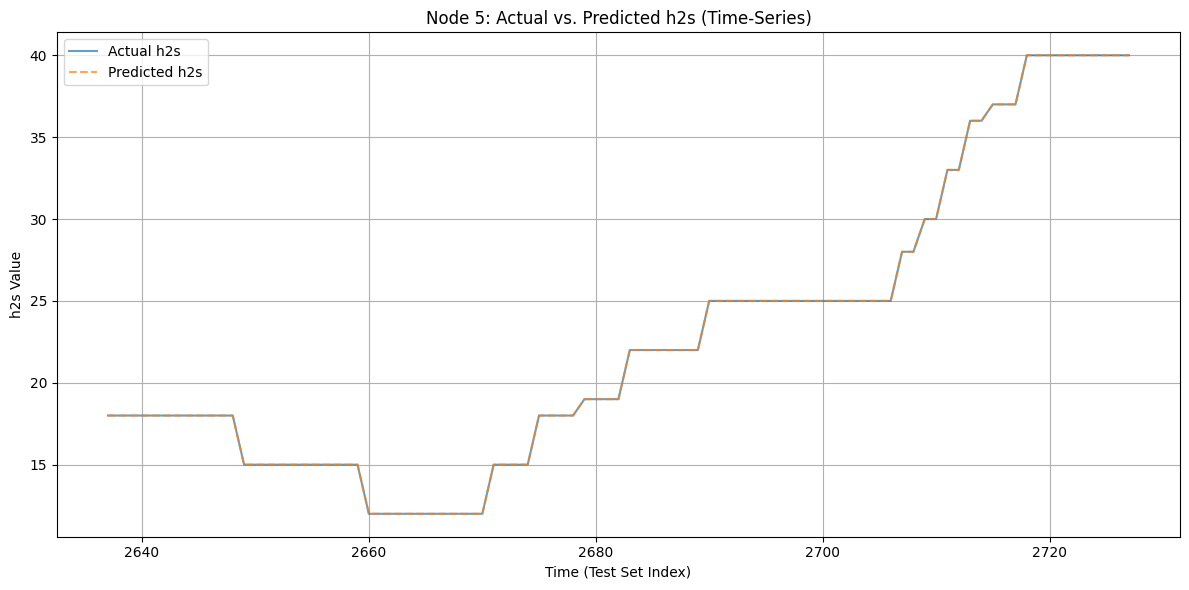

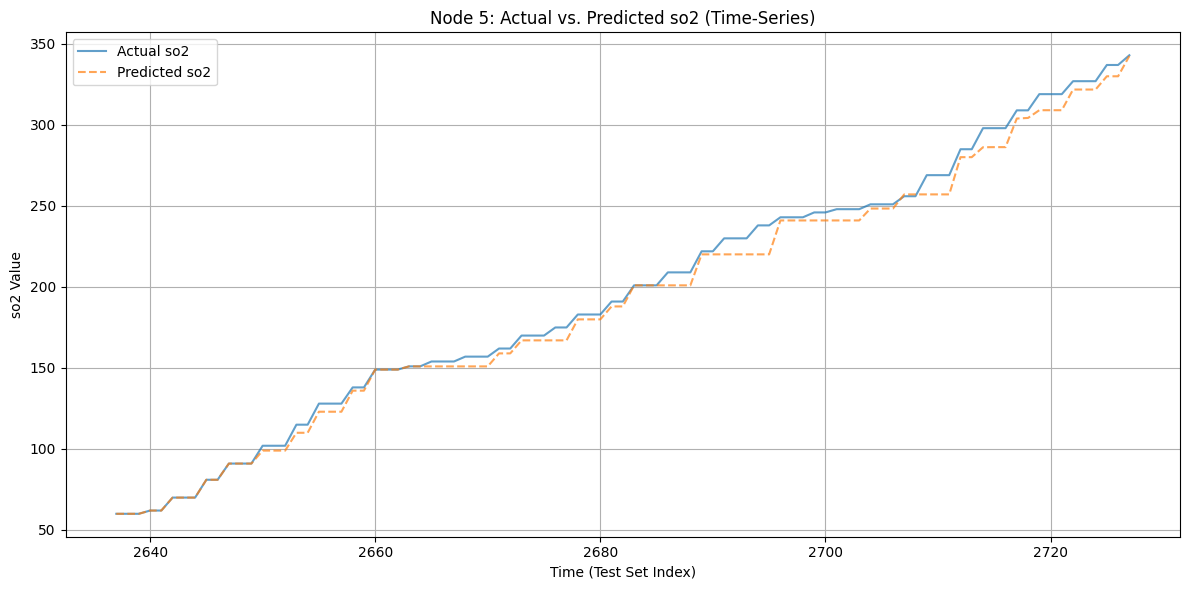


Visualisasi Time-Series untuk Node 6:


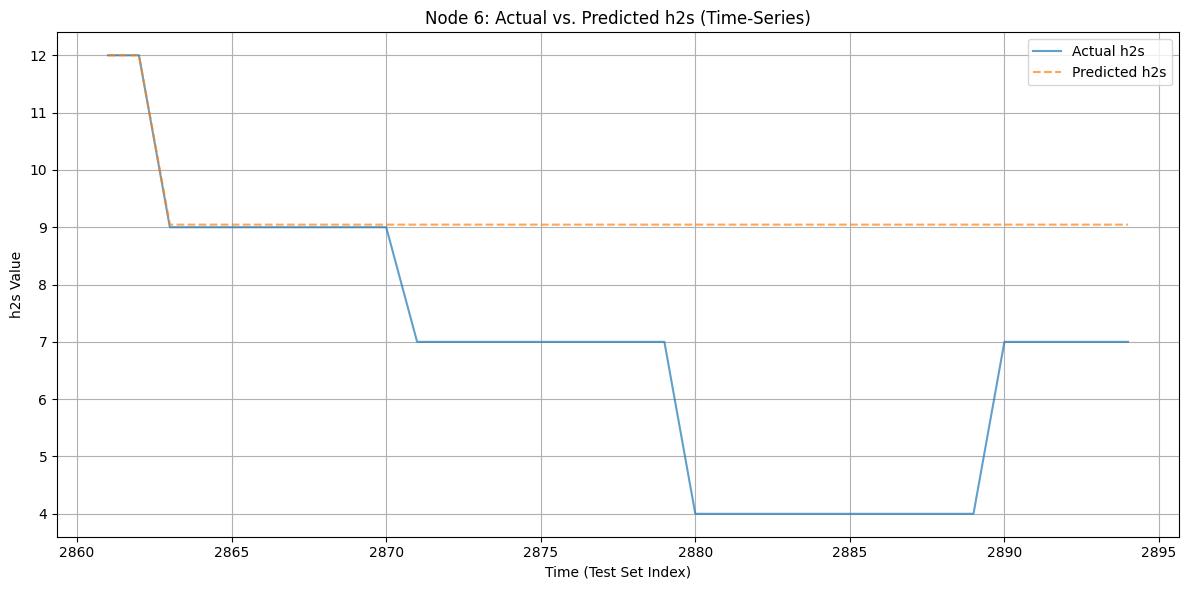

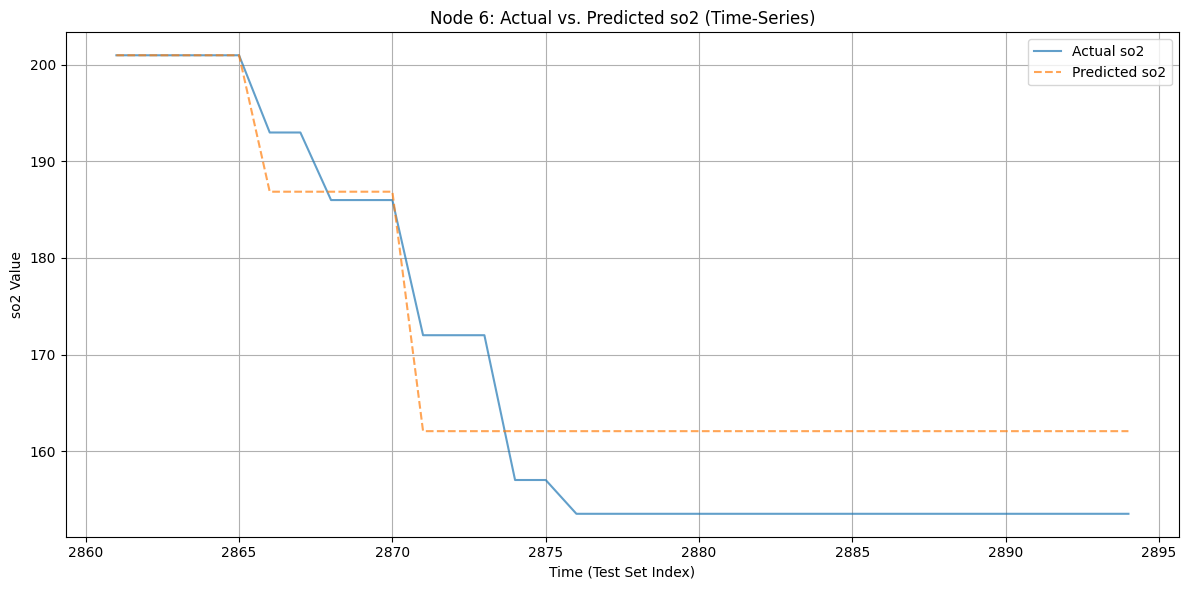


Visualisasi Time-Series selesai untuk semua node dan target.


In [ ]:
print("\n======== Visualisasi Time-Series Prediksi vs. Aktual Model XGBosst ========\n")

for i in range(1, 7):
    node_key = f'node_{i}'
    if node_key not in test_data_for_eval:
        print(f"Warning: No evaluation data found for {node_key}. Skipping time-series visualization.")
        continue

    # X_test, y_test, and y_pred already contain the processed data (after capping).
    # No inverse scaling is needed as the 'cap' strategy was used, not 'robust' scaling.
    y_test_plot = test_data_for_eval[node_key]['y_test']
    y_pred_plot = test_data_for_eval[node_key]['y_pred']

    print(f"\nVisualisasi Time-Series untuk Node {i}:")

    # Iterate through each target column (h2s, so2)
    for j, target_col in enumerate(TARGET_COLS):
        plt.figure(figsize=(12, 6))

        # Plot actual values
        plt.plot(y_test_plot.index, y_test_plot[target_col], label=f'Actual {target_col}', alpha=0.7)
        # Plot predicted values
        # y_pred_plot is a numpy array, access the column using index j
        plt.plot(y_test_plot.index, y_pred_plot[:, j], label=f'Predicted {target_col}', alpha=0.7, linestyle='--')

        plt.title(f'Node {i}: Actual vs. Predicted {target_col} (Time-Series)')
        plt.xlabel('Time (Test Set Index)')
        plt.ylabel(f'{target_col} Value')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

print("\nVisualisasi Time-Series selesai untuk semua node dan target.")

In [ ]:
from sklearn.ensemble import RandomForestRegressor

models_rf = {}
test_data_for_eval_rf = {}

for i in range(1, 7):
    df_name = f"df{i}"
    if df_name not in globals():
        print(f"Warning: {df_name} not found. Skipping RandomForest model training for this node.")
        continue

    print(f"\n======== Training RandomForest model for {df_name} (Node {i}) ========\n")
    df_node = globals()[df_name].copy()

    # Drop rows with NaN in features or targets
    df_node.dropna(subset=FEATURE_COLS + TARGET_COLS, inplace=True)

    X = df_node[FEATURE_COLS]
    y = df_node[TARGET_COLS]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, shuffle=False
    )

    # Initialize RandomForest Regressor
    rf_reg = RandomForestRegressor(
        n_estimators=100,
        random_state=SEED,
        n_jobs=-1 # Use all available cores
    )

    # Wrap RandomForest with MultiOutputRegressor
    multi_output_rf = MultiOutputRegressor(rf_reg)

    # Train the model
    multi_output_rf.fit(X_train, y_train)

    # Store the trained model
    models_rf[f'node_{i}'] = multi_output_rf

    # Make predictions on the test set
    y_pred = multi_output_rf.predict(X_test)

    # Store X_test, y_test and y_pred for later evaluation and visualization
    test_data_for_eval_rf[f'node_{i}'] = {
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred
    }

print("\nRandomForest model training completed for all specified nodes.")


======== Training RandomForest model for df1 (Node 1) ========


======== Training RandomForest model for df2 (Node 2) ========


======== Training RandomForest model for df3 (Node 3) ========


======== Training RandomForest model for df4 (Node 4) ========


======== Training RandomForest model for df5 (Node 5) ========


======== Training RandomForest model for df6 (Node 6) ========


RandomForest model training completed for all specified nodes.


In [ ]:
print("\n======== RandomForest Model Evaluation ========\n")

evaluation_metrics_summary_rf = {}

for i in range(1, 7):
    node_key = f'node_{i}'
    if node_key not in test_data_for_eval_rf:
        print(f"Warning: No RandomForest evaluation data found for {node_key}. Skipping evaluation.")
        continue

    y_test = test_data_for_eval_rf[node_key]['y_test']
    y_pred = test_data_for_eval_rf[node_key]['y_pred']

    node_metrics = {}
    print(f"\nEvaluation for RandomForest Node {i}:")
    for j, target_col in enumerate(TARGET_COLS):
        mse = mean_squared_error(y_test[target_col], y_pred[:, j])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test[target_col], y_pred[:, j])
        r2 = r2_score(y_test[target_col], y_pred[:, j])

        print(f"  Target: {target_col}")
        print(f"    Mean Squared Error (MSE): {mse:.4f}")
        print(f"    Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"    Mean Absolute Error (MAE): {mae:.4f}")
        print(f"    R-squared (R2): {r2:.4f}")
        node_metrics[target_col] = {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}
    evaluation_metrics_summary_rf[node_key] = node_metrics

print("\nRandomForest model evaluation completed for all specified nodes.")


======== RandomForest Model Evaluation ========


Evaluation for RandomForest Node 1:
  Target: h2s
    Mean Squared Error (MSE): 40.8340
    Root Mean Squared Error (RMSE): 6.3901
    Mean Absolute Error (MAE): 3.6058
    R-squared (R2): 0.9955
  Target: so2
    Mean Squared Error (MSE): 252.6742
    Root Mean Squared Error (RMSE): 15.8957
    Mean Absolute Error (MAE): 9.0097
    R-squared (R2): 0.9955

Evaluation for RandomForest Node 2:
  Target: h2s
    Mean Squared Error (MSE): 0.7093
    Root Mean Squared Error (RMSE): 0.8422
    Mean Absolute Error (MAE): 0.2727
    R-squared (R2): 0.9663
  Target: so2
    Mean Squared Error (MSE): 0.7121
    Root Mean Squared Error (RMSE): 0.8439
    Mean Absolute Error (MAE): 0.5702
    R-squared (R2): 0.9911

Evaluation for RandomForest Node 3:
  Target: h2s
    Mean Squared Error (MSE): 70.6205
    Root Mean Squared Error (RMSE): 8.4036
    Mean Absolute Error (MAE): 5.2020
    R-squared (R2): 0.8532
  Target: so2
    Mean Squared Error (M


======== Visualisasi Time-Series Prediksi vs. Aktual Model RandomForest ========


Visualisasi Time-Series untuk Node 1 (RandomForest):


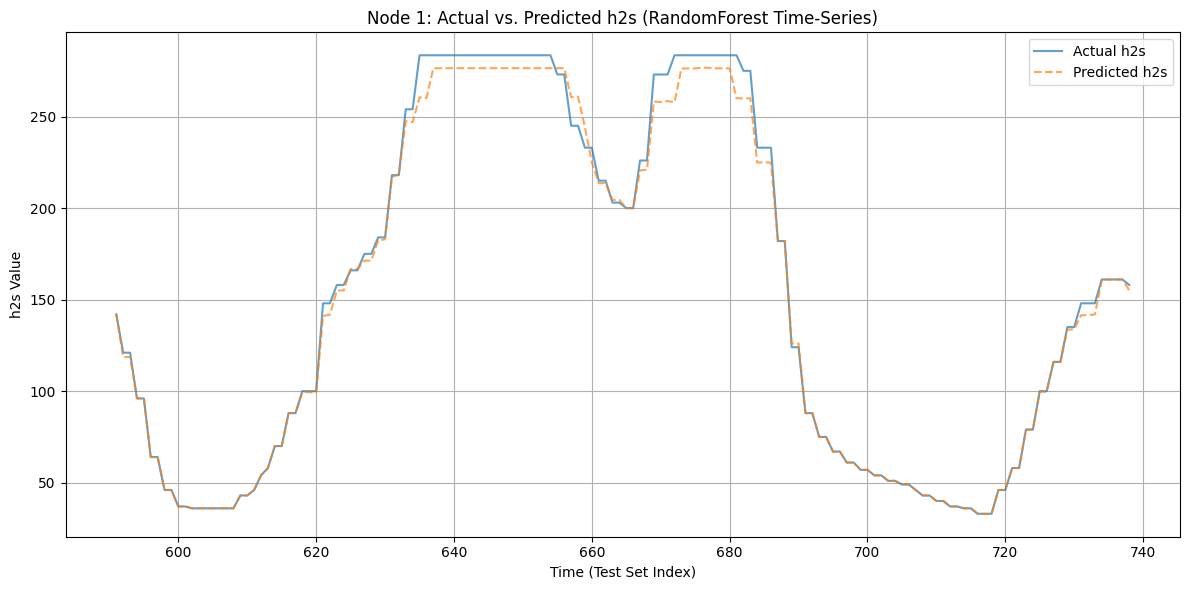

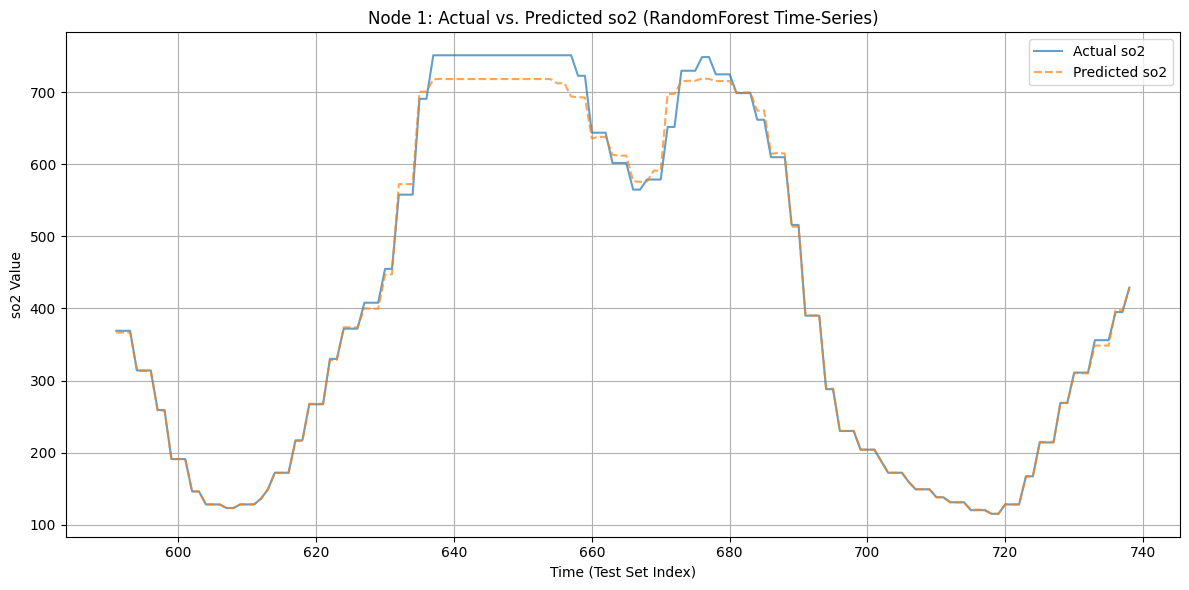


Visualisasi Time-Series untuk Node 2 (RandomForest):


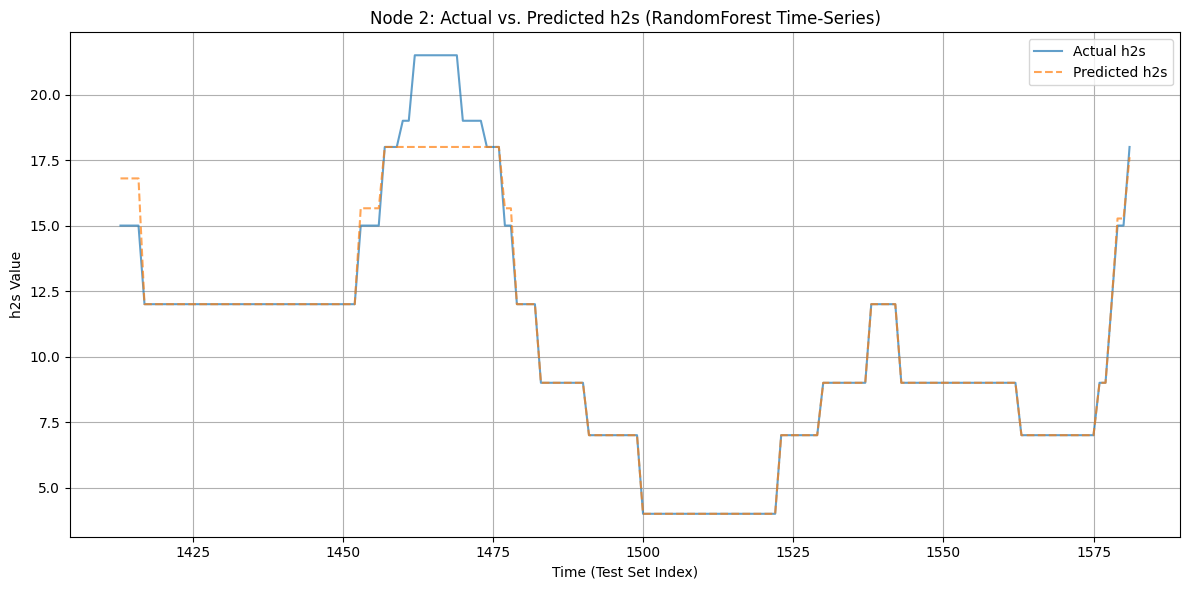

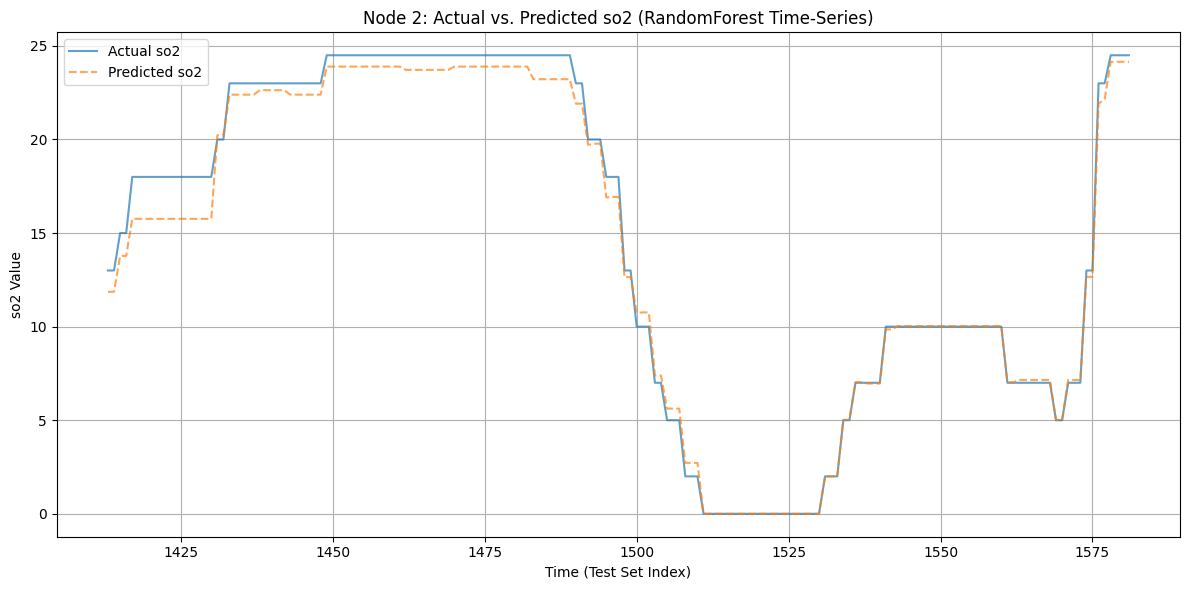


Visualisasi Time-Series untuk Node 3 (RandomForest):


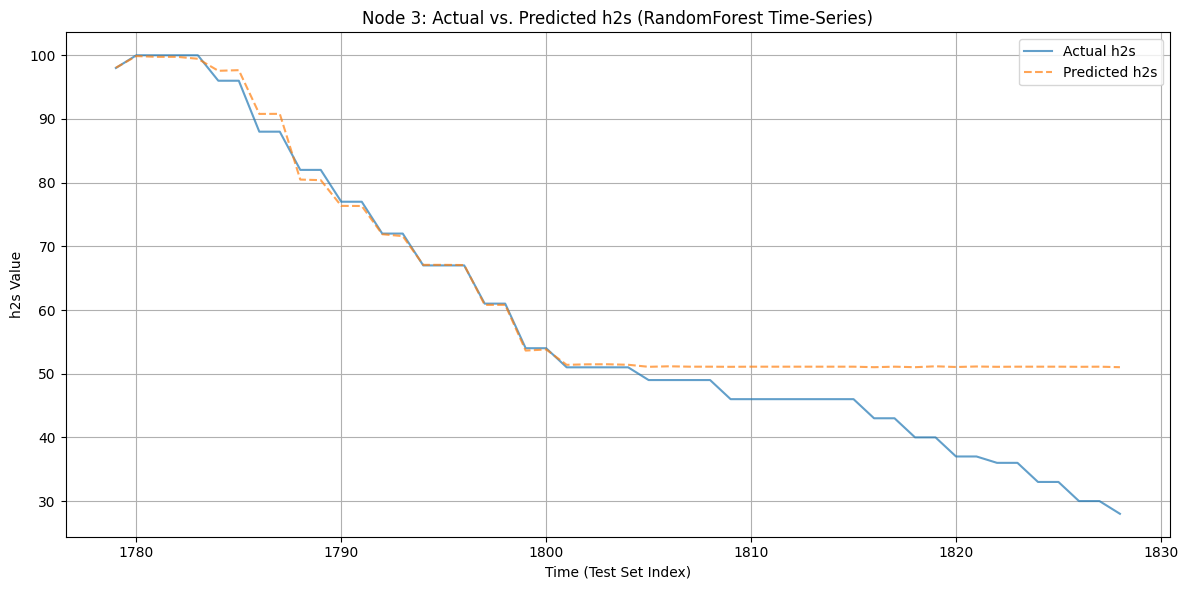

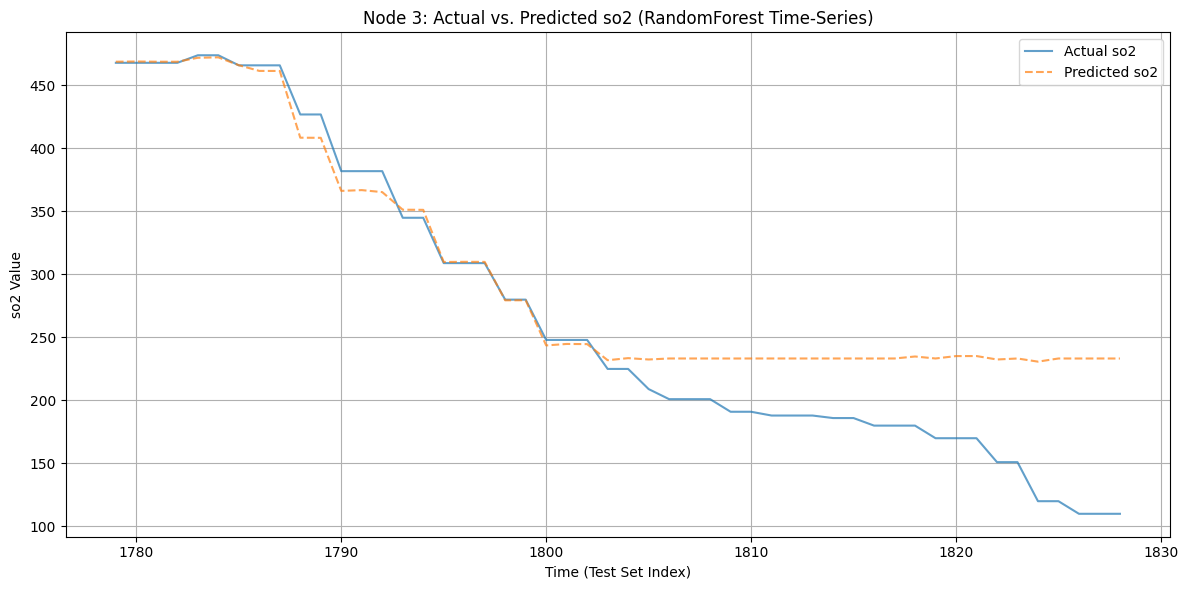


Visualisasi Time-Series untuk Node 4 (RandomForest):


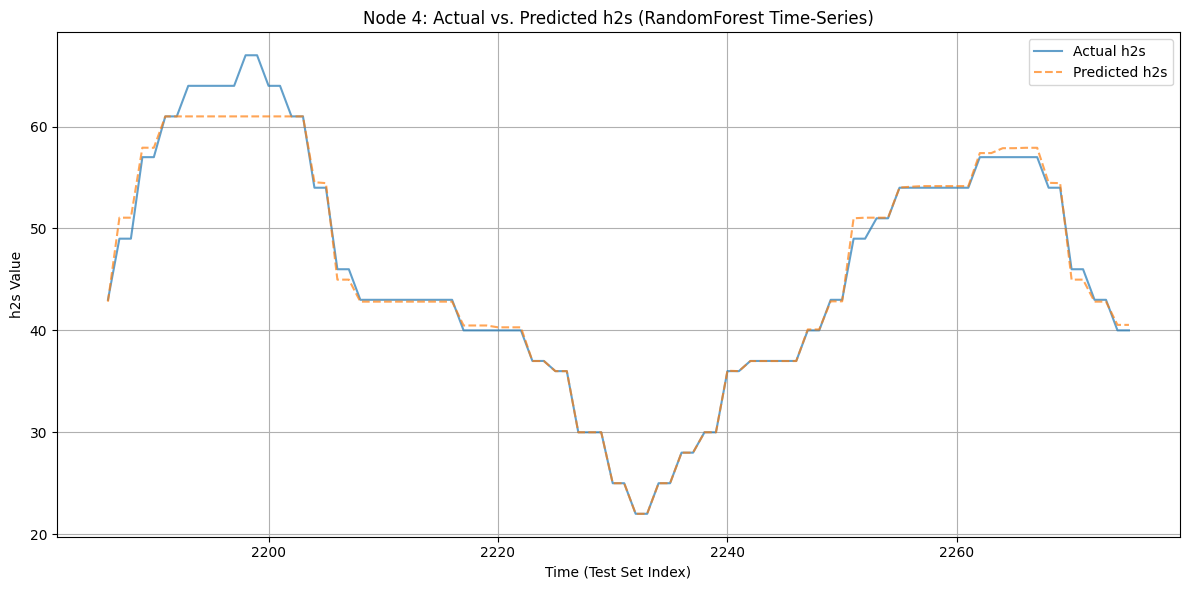

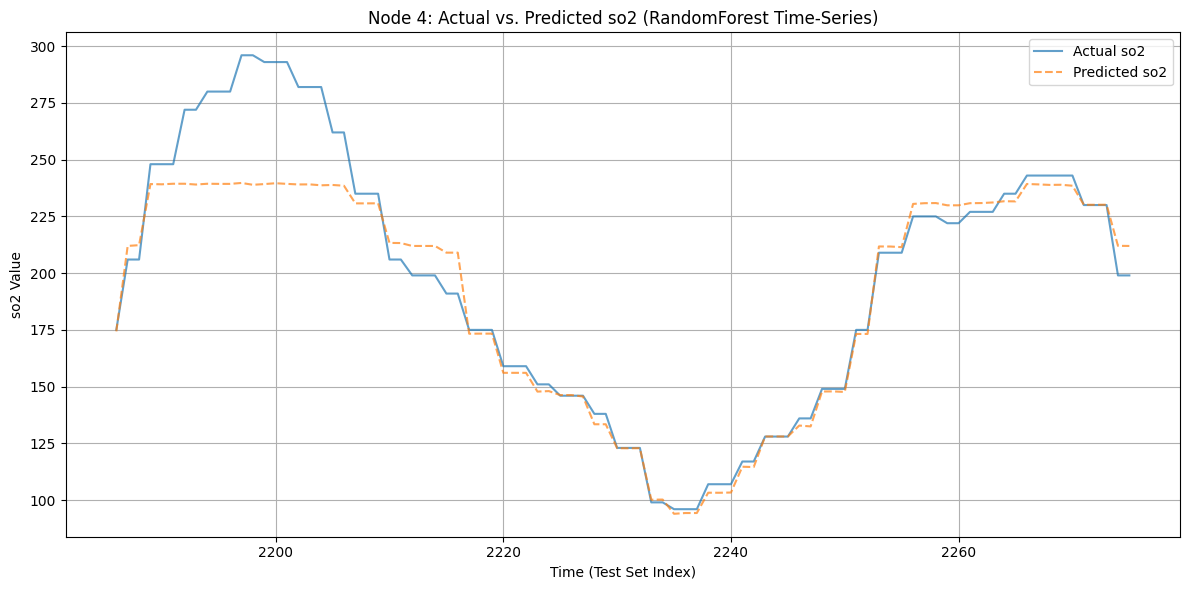


Visualisasi Time-Series untuk Node 5 (RandomForest):


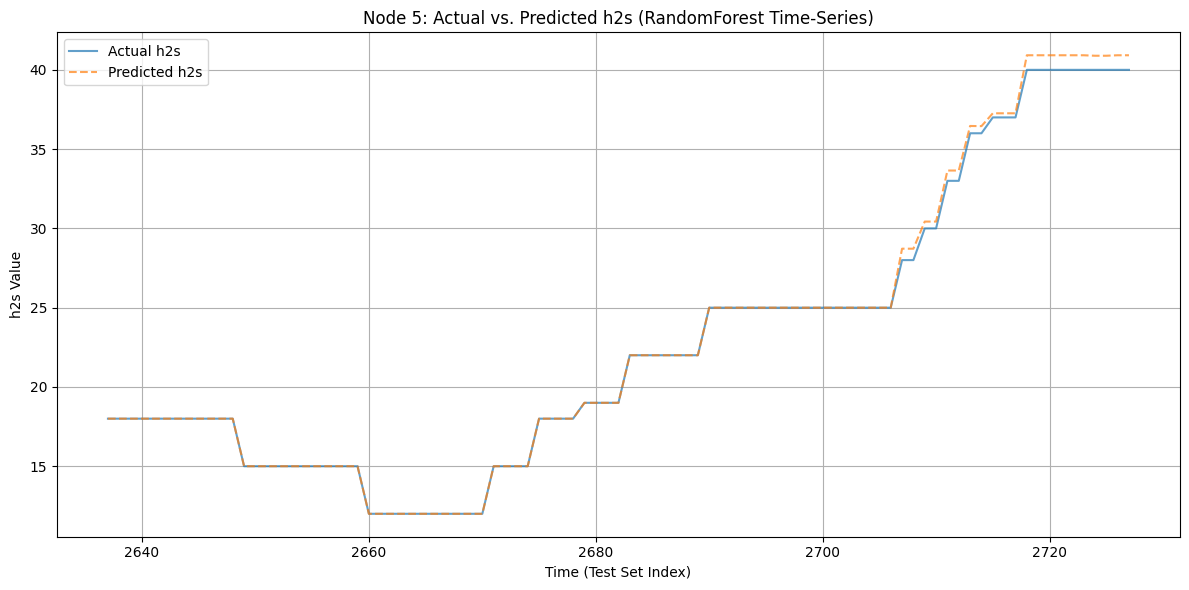

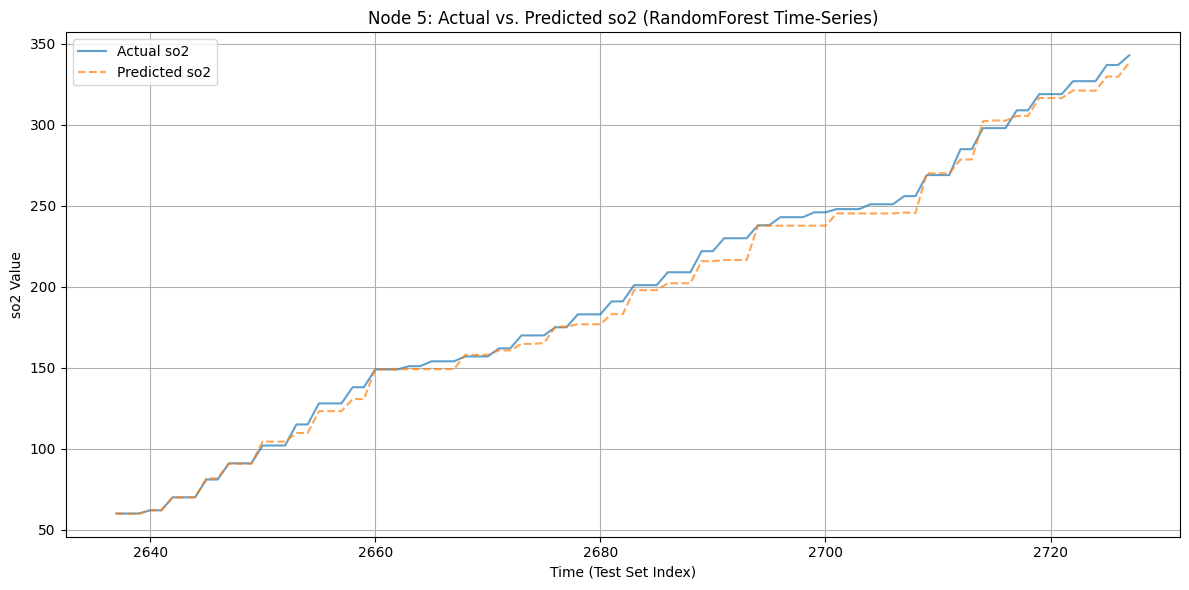


Visualisasi Time-Series untuk Node 6 (RandomForest):


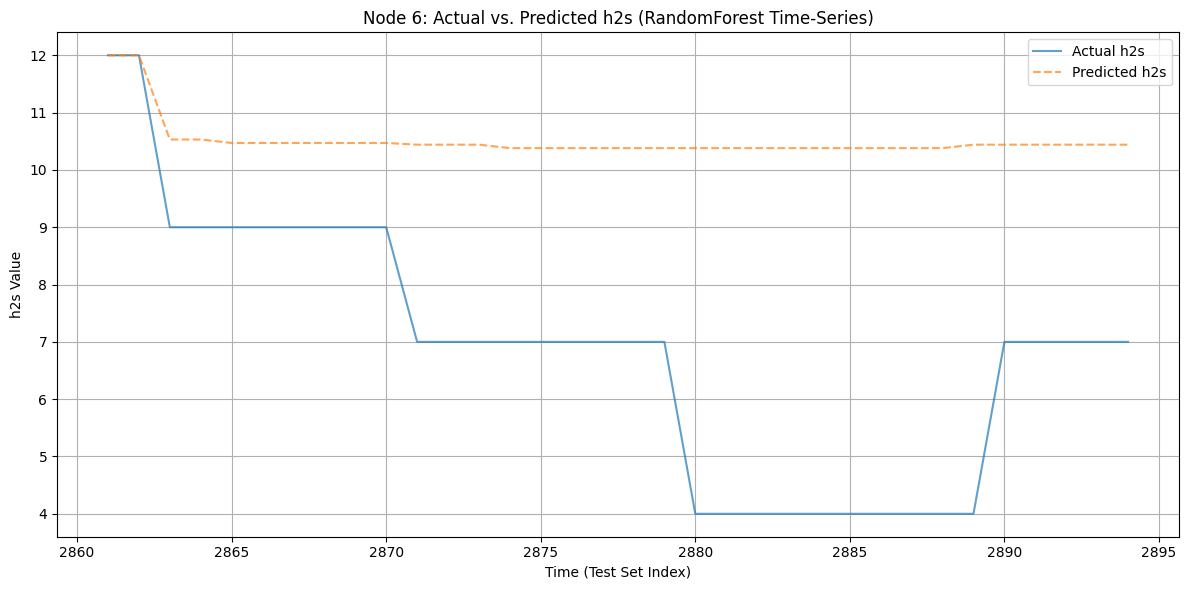

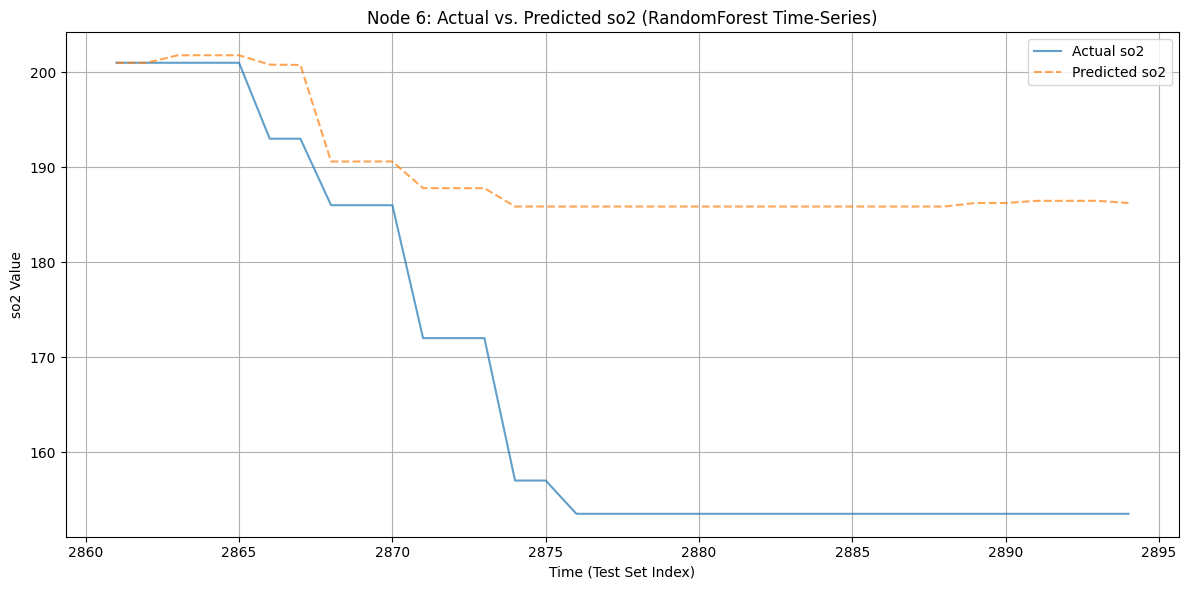


Visualisasi Time-Series (RandomForest) selesai untuk semua node dan target.


In [ ]:
print("\n======== Visualisasi Time-Series Prediksi vs. Aktual Model RandomForest ========\n")

for i in range(1, 7):
    node_key = f'node_{i}'
    if node_key not in test_data_for_eval_rf:
        print(f"Warning: No evaluation data found for {node_key}. Skipping time-series visualization for RandomForest.")
        continue

    y_test_plot_rf = test_data_for_eval_rf[node_key]['y_test']
    y_pred_plot_rf = test_data_for_eval_rf[node_key]['y_pred']

    print(f"\nVisualisasi Time-Series untuk Node {i} (RandomForest):")

    for j, target_col in enumerate(TARGET_COLS):
        plt.figure(figsize=(12, 6))

        # Plot actual values
        plt.plot(y_test_plot_rf.index, y_test_plot_rf[target_col], label=f'Actual {target_col}', alpha=0.7)
        # Plot predicted values
        plt.plot(y_test_plot_rf.index, y_pred_plot_rf[:, j], label=f'Predicted {target_col}', alpha=0.7, linestyle='--')

        plt.title(f'Node {i}: Actual vs. Predicted {target_col} (RandomForest Time-Series)')
        plt.xlabel('Time (Test Set Index)')
        plt.ylabel(f'{target_col} Value')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

print("\nVisualisasi Time-Series (RandomForest) selesai untuk semua node dan target.")

In [ ]:
from sklearn.svm import SVR

models_svr = {}
test_data_for_eval_svr = {}

for i in range(1, 7):
    df_name = f"df{i}"
    if df_name not in globals():
        print(f"Warning: {df_name} not found. Skipping SVR model training for this node.")
        continue

    print(f"\n======== Training SVR model for {df_name} (Node {i}) ========\n")
    df_node = globals()[df_name].copy()

    # Drop rows with NaN in features or targets
    df_node.dropna(subset=FEATURE_COLS + TARGET_COLS, inplace=True)

    X = df_node[FEATURE_COLS]
    y = df_node[TARGET_COLS]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, shuffle=False
    )

    # Initialize SVR Regressor
    # SVR does not natively support multi-output, so we wrap it
    svr_reg = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)

    # Wrap SVR with MultiOutputRegressor
    multi_output_svr = MultiOutputRegressor(svr_reg)

    # Train the model
    multi_output_svr.fit(X_train, y_train)

    # Store the trained model
    models_svr[f'node_{i}'] = multi_output_svr

    # Make predictions on the test set
    y_pred = multi_output_svr.predict(X_test)

    # Store X_test, y_test and y_pred for later evaluation and visualization
    test_data_for_eval_svr[f'node_{i}'] = {
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred
    }

print("\nSVR model training completed for all specified nodes.")


======== Training SVR model for df1 (Node 1) ========


======== Training SVR model for df2 (Node 2) ========


======== Training SVR model for df3 (Node 3) ========


======== Training SVR model for df4 (Node 4) ========


======== Training SVR model for df5 (Node 5) ========


======== Training SVR model for df6 (Node 6) ========


SVR model training completed for all specified nodes.


In [ ]:
print("\n======== SVR Model Evaluation ========\n")

evaluation_metrics_summary_svr = {}

for i in range(1, 7):
    node_key = f'node_{i}'
    if node_key not in test_data_for_eval_svr:
        print(f"Warning: No SVR evaluation data found for {node_key}. Skipping evaluation.")
        continue

    y_test = test_data_for_eval_svr[node_key]['y_test']
    y_pred = test_data_for_eval_svr[node_key]['y_pred']

    node_metrics = {}
    print(f"\nEvaluation for SVR Node {i}:")
    for j, target_col in enumerate(TARGET_COLS):
        mse = mean_squared_error(y_test[target_col], y_pred[:, j])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test[target_col], y_pred[:, j])
        r2 = r2_score(y_test[target_col], y_pred[:, j])

        print(f"  Target: {target_col}")
        print(f"    Mean Squared Error (MSE): {mse:.4f}")
        print(f"    Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"    Mean Absolute Error (MAE): {mae:.4f}")
        print(f"    R-squared (R2): {r2:.4f}")
        node_metrics[target_col] = {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}
    evaluation_metrics_summary_svr[node_key] = node_metrics

print("\nSVR model evaluation completed for all specified nodes.")


======== SVR Model Evaluation ========


Evaluation for SVR Node 1:
  Target: h2s
    Mean Squared Error (MSE): 13876.8398
    Root Mean Squared Error (RMSE): 117.8000
    Mean Absolute Error (MAE): 93.8304
    R-squared (R2): -0.5409
  Target: so2
    Mean Squared Error (MSE): 95864.3833
    Root Mean Squared Error (RMSE): 309.6197
    Mean Absolute Error (MAE): 238.8520
    R-squared (R2): -0.7055

Evaluation for SVR Node 2:
  Target: h2s
    Mean Squared Error (MSE): 28.8421
    Root Mean Squared Error (RMSE): 5.3705
    Mean Absolute Error (MAE): 4.0451
    R-squared (R2): -0.3715
  Target: so2
    Mean Squared Error (MSE): 149.0858
    Root Mean Squared Error (RMSE): 12.2101
    Mean Absolute Error (MAE): 10.1745
    R-squared (R2): -0.8573

Evaluation for SVR Node 3:
  Target: h2s
    Mean Squared Error (MSE): 3415.8025
    Root Mean Squared Error (RMSE): 58.4449
    Mean Absolute Error (MAE): 53.5184
    R-squared (R2): -6.1006
  Target: so2
    Mean Squared Error (MSE): 65482.


======== Visualisasi Time-Series Prediksi vs. Aktual Model SVR ========


Visualisasi Time-Series untuk Node 1 (SVR):


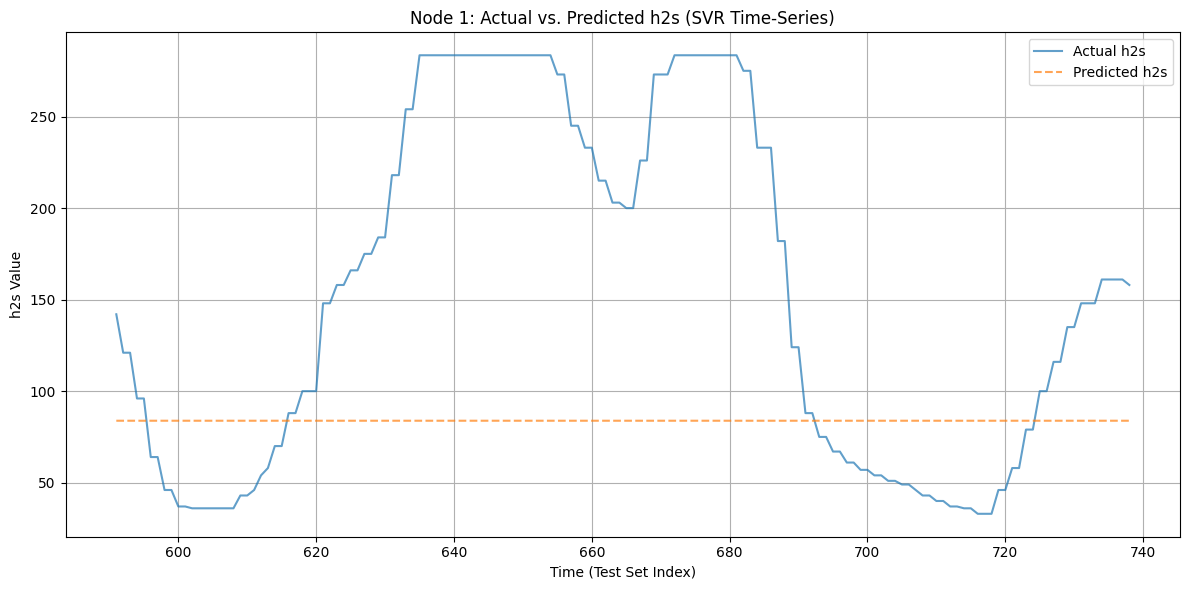

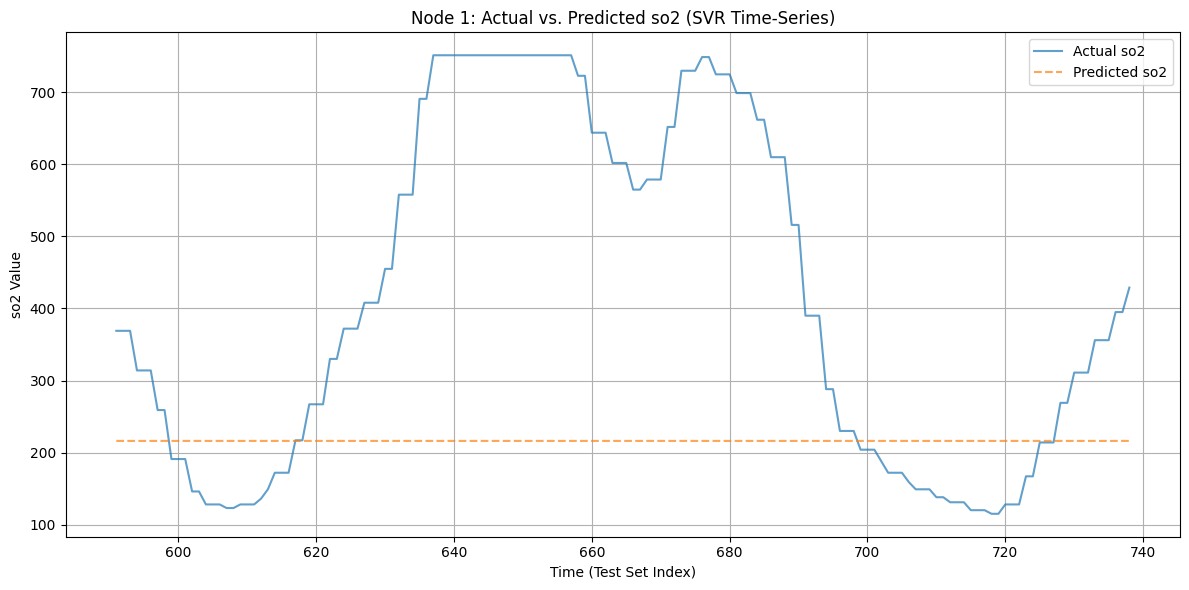


Visualisasi Time-Series untuk Node 2 (SVR):


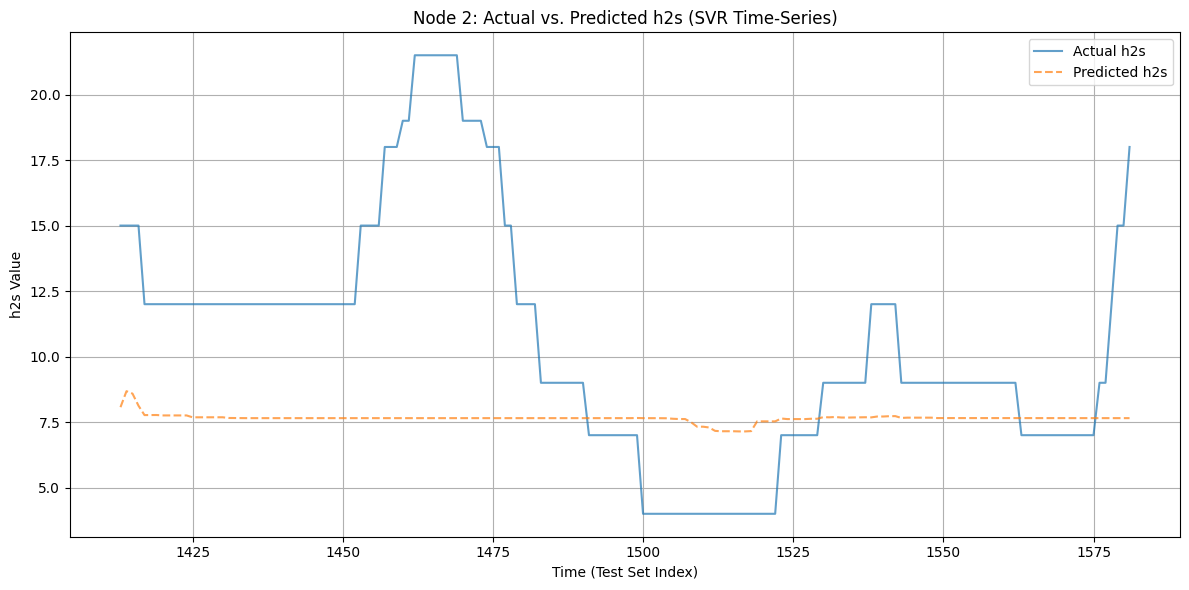

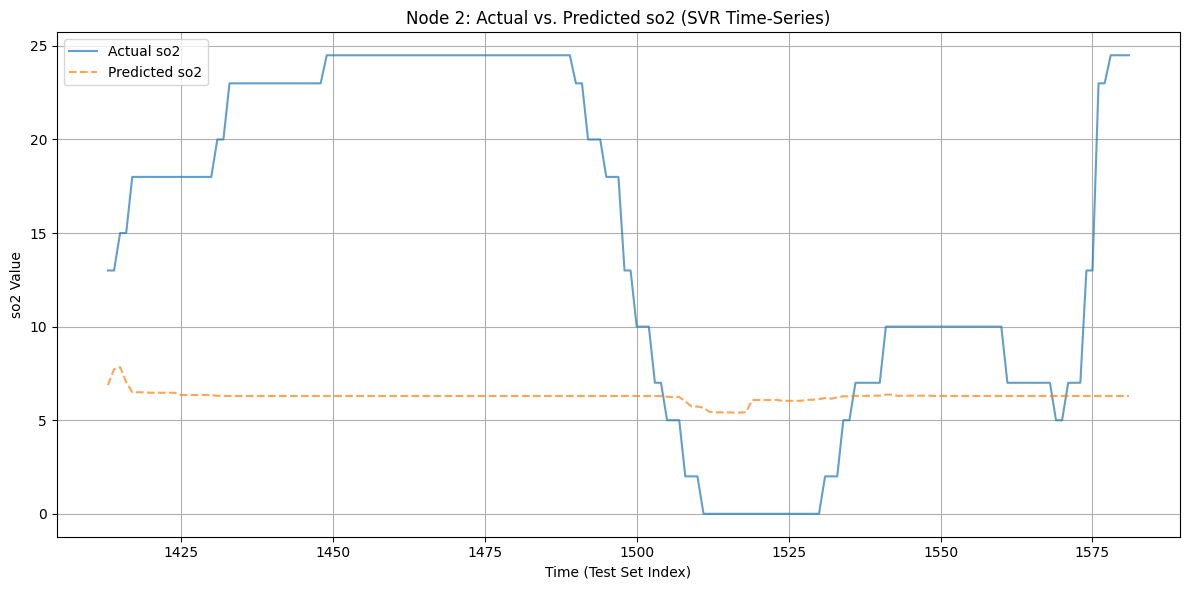


Visualisasi Time-Series untuk Node 3 (SVR):


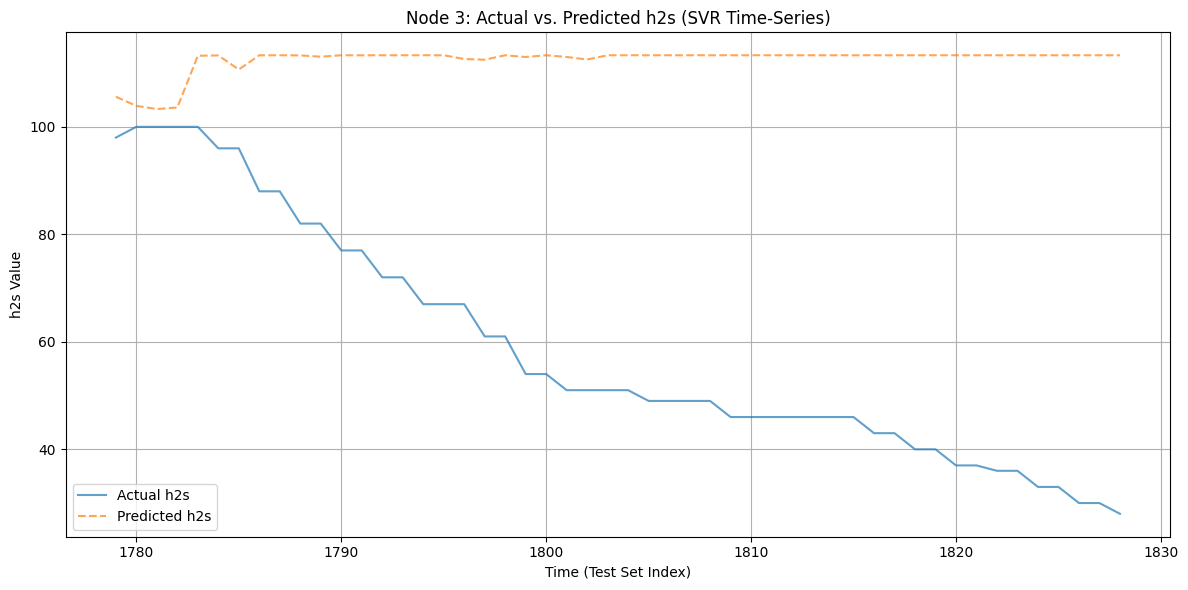

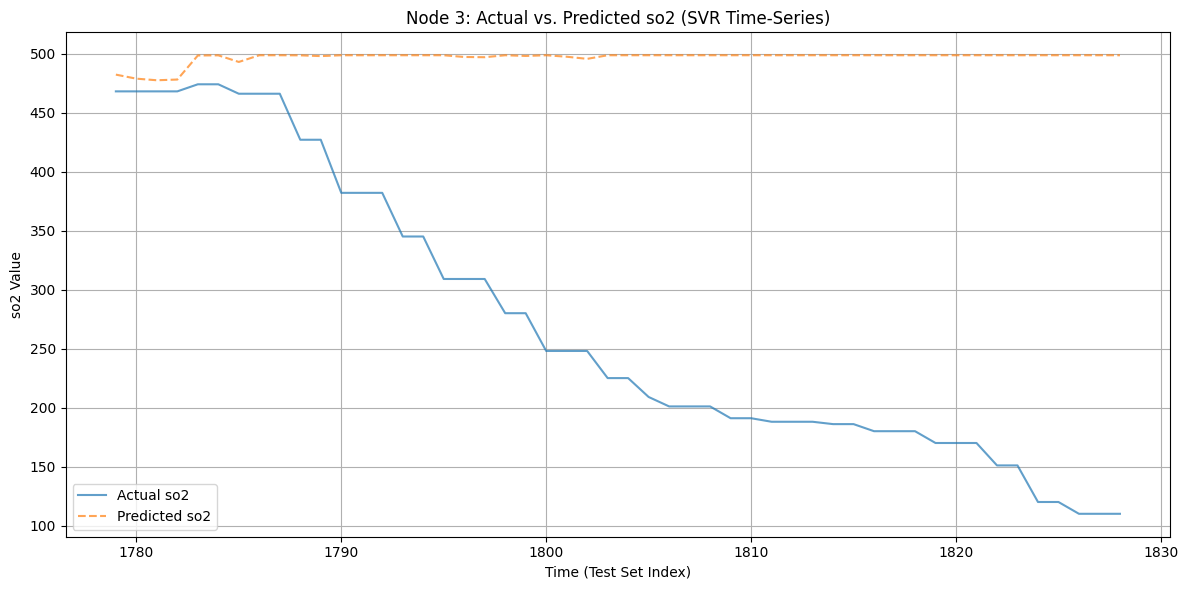


Visualisasi Time-Series untuk Node 4 (SVR):


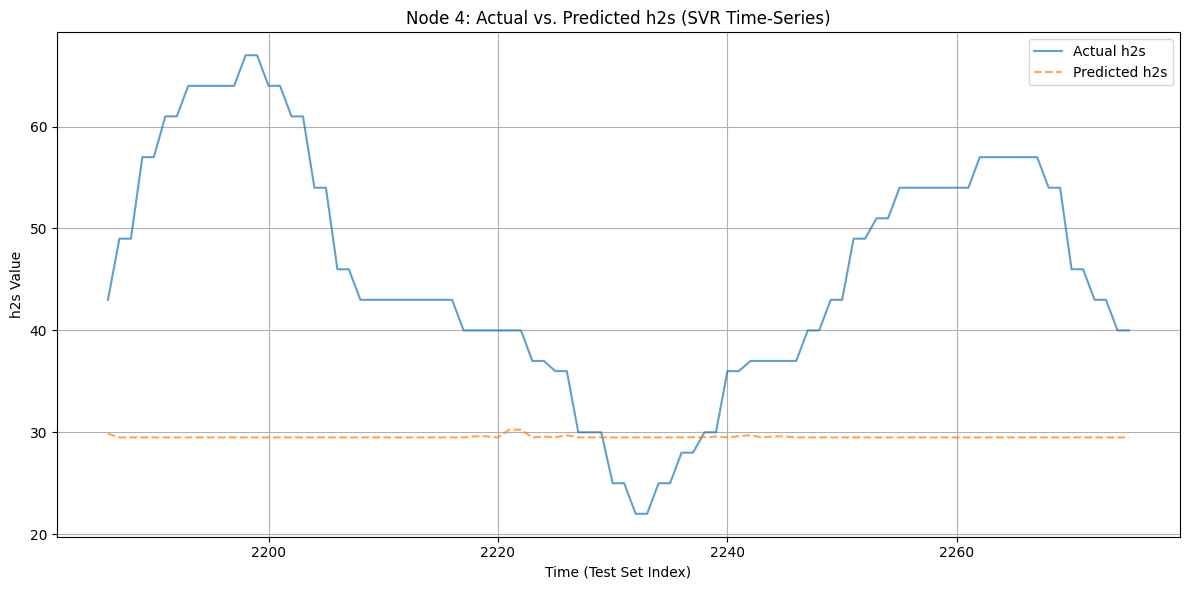

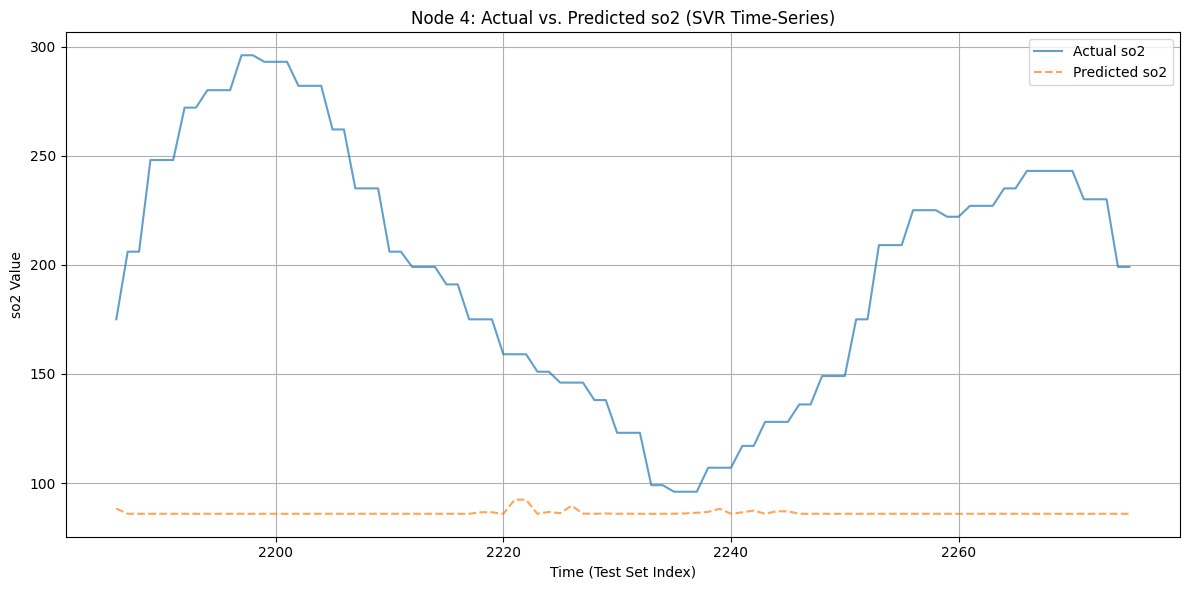


Visualisasi Time-Series untuk Node 5 (SVR):


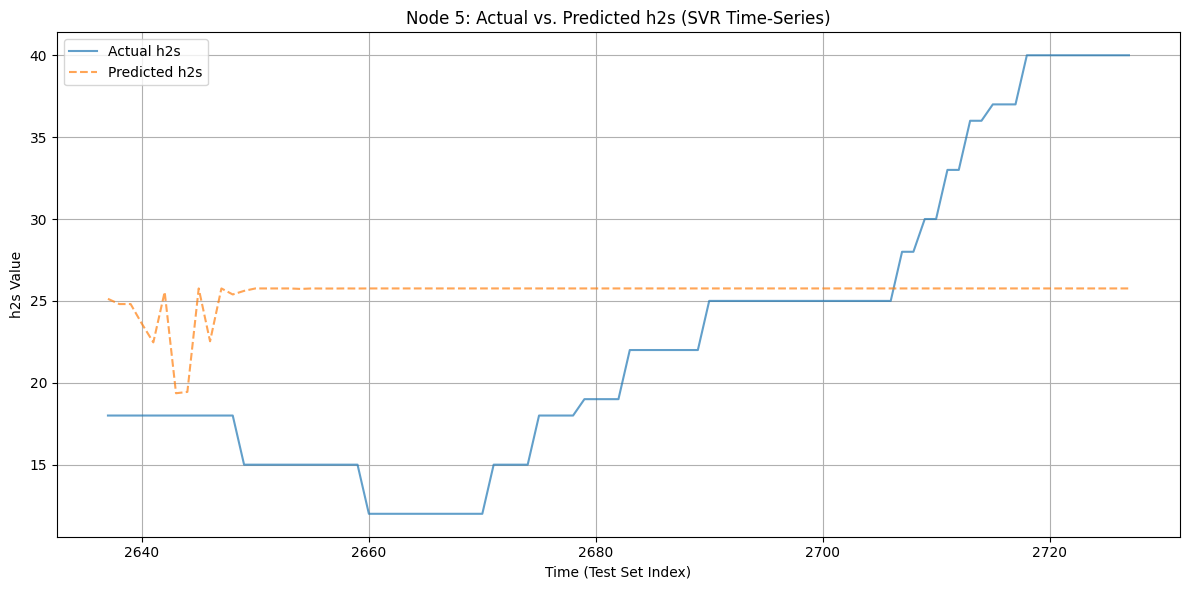

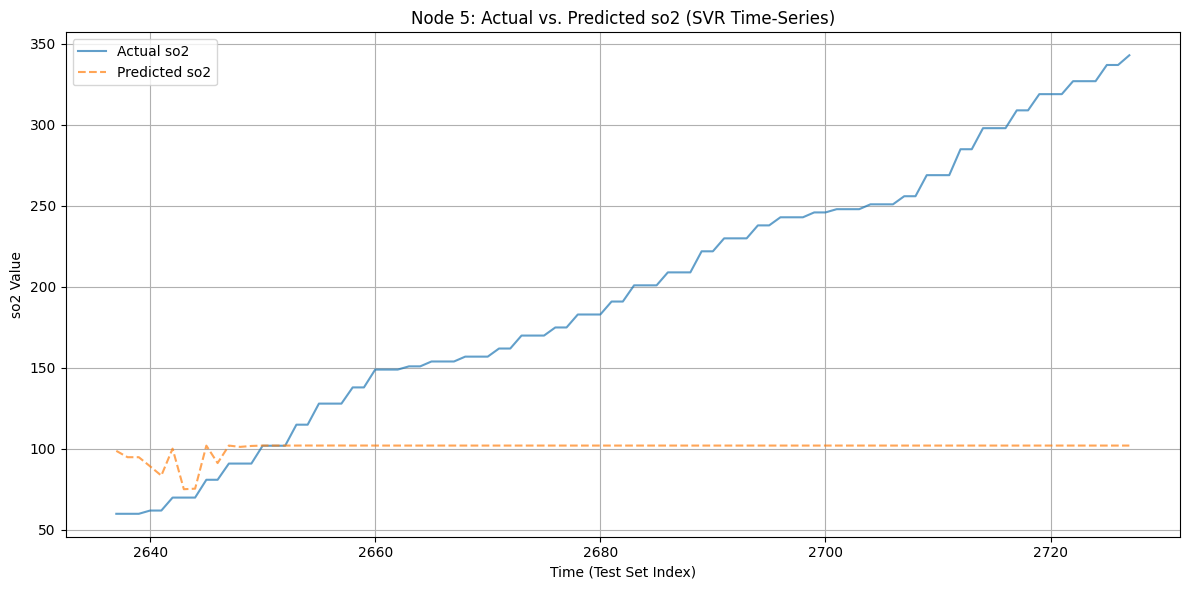


Visualisasi Time-Series untuk Node 6 (SVR):


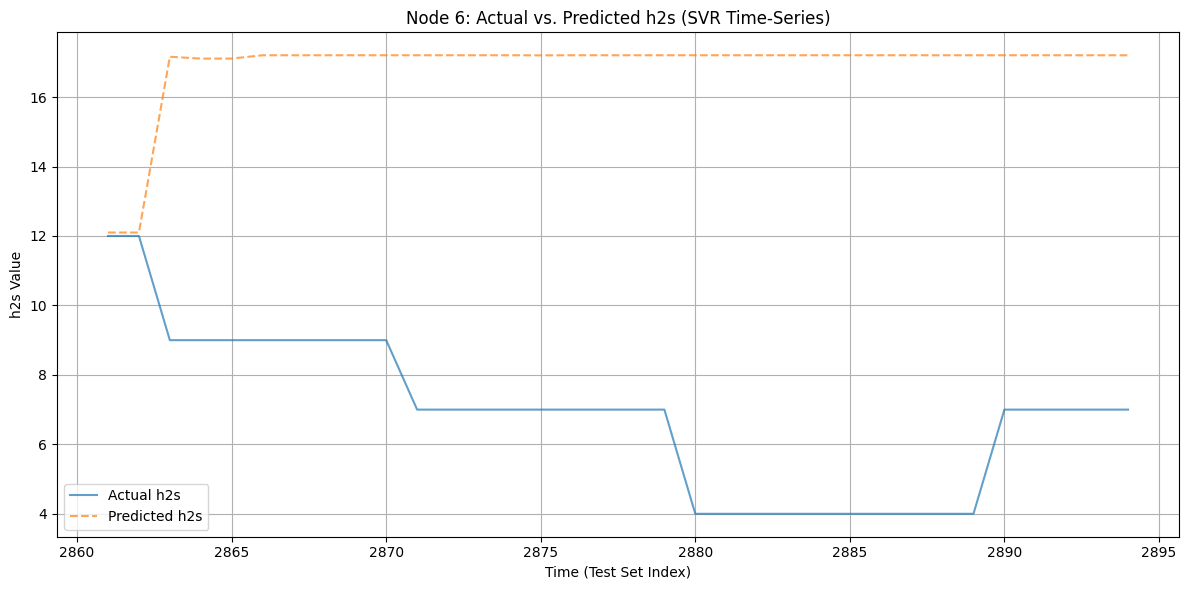

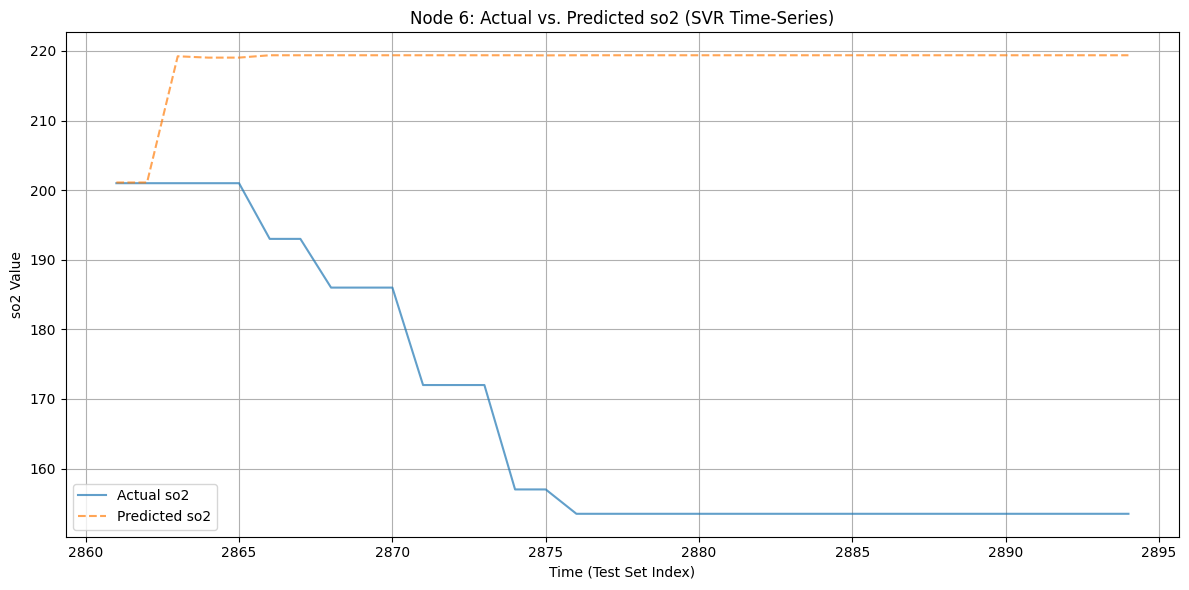


Visualisasi Time-Series (SVR) selesai untuk semua node dan target.


In [ ]:
print("\n======== Visualisasi Time-Series Prediksi vs. Aktual Model SVR ========\n")

for i in range(1, 7):
    node_key = f'node_{i}'
    if node_key not in test_data_for_eval_svr:
        print(f"Warning: No evaluation data found for {node_key}. Skipping time-series visualization for SVR.")
        continue

    y_test_plot_svr = test_data_for_eval_svr[node_key]['y_test']
    y_pred_plot_svr = test_data_for_eval_svr[node_key]['y_pred']

    print(f"\nVisualisasi Time-Series untuk Node {i} (SVR):")

    for j, target_col in enumerate(TARGET_COLS):
        plt.figure(figsize=(12, 6))

        # Plot actual values
        plt.plot(y_test_plot_svr.index, y_test_plot_svr[target_col], label=f'Actual {target_col}', alpha=0.7)
        # Plot predicted values
        plt.plot(y_test_plot_svr.index, y_pred_plot_svr[:, j], label=f'Predicted {target_col}', alpha=0.7, linestyle='--')

        plt.title(f'Node {i}: Actual vs. Predicted {target_col} (SVR Time-Series)')
        plt.xlabel('Time (Test Set Index)')
        plt.ylabel(f'{target_col} Value')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

print("\nVisualisasi Time-Series (SVR) selesai untuk semua node dan target.")

In [ ]:
import pickle
import os

# Create a directory to save models if it doesn't exist
model_save_dir = "./trained_models"
os.makedirs(model_save_dir, exist_ok=True)

print(f"Menyimpan model ke direktori: {model_save_dir}")

# Save XGBoost models
for node_key, model in models.items():
    filename = os.path.join(model_save_dir, f"{node_key}_xgb.pkl")
    try:
        with open(filename, 'wb') as file:
            pickle.dump(model, file)
        print(f"Model {node_key} (XGBoost) berhasil disimpan ke {filename}")
    except Exception as e:
        print(f"Gagal menyimpan model {node_key} (XGBoost): {e}")

# Save RandomForest models
for node_key, model in models_rf.items():
    filename = os.path.join(model_save_dir, f"{node_key}_rf.pkl")
    try:
        with open(filename, 'wb') as file:
            pickle.dump(model, file)
        print(f"Model {node_key} (RandomForest) berhasil disimpan ke {filename}")
    except Exception as e:
        print(f"Gagal menyimpan model {node_key} (RandomForest): {e}")

# Save SVR models
for node_key, model in models_svr.items():
    filename = os.path.join(model_save_dir, f"{node_key}_svr.pkl")
    try:
        with open(filename, 'wb') as file:
            pickle.dump(model, file)
        print(f"Model {node_key} (SVR) berhasil disimpan ke {filename}")
    except Exception as e:
        print(f"Gagal menyimpan model {node_key} (SVR): {e}")

print("Proses penyimpanan semua model selesai.")

Menyimpan model ke direktori: ./trained_models
Model node_1 (XGBoost) berhasil disimpan ke ./trained_models/node_1_xgb.pkl
Model node_2 (XGBoost) berhasil disimpan ke ./trained_models/node_2_xgb.pkl
Model node_3 (XGBoost) berhasil disimpan ke ./trained_models/node_3_xgb.pkl
Model node_4 (XGBoost) berhasil disimpan ke ./trained_models/node_4_xgb.pkl
Model node_5 (XGBoost) berhasil disimpan ke ./trained_models/node_5_xgb.pkl
Model node_6 (XGBoost) berhasil disimpan ke ./trained_models/node_6_xgb.pkl
Model node_1 (RandomForest) berhasil disimpan ke ./trained_models/node_1_rf.pkl
Model node_2 (RandomForest) berhasil disimpan ke ./trained_models/node_2_rf.pkl
Model node_3 (RandomForest) berhasil disimpan ke ./trained_models/node_3_rf.pkl
Model node_4 (RandomForest) berhasil disimpan ke ./trained_models/node_4_rf.pkl
Model node_5 (RandomForest) berhasil disimpan ke ./trained_models/node_5_rf.pkl
Model node_6 (RandomForest) berhasil disimpan ke ./trained_models/node_6_rf.pkl
Model node_1 (SVR